<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🔁 Modelos Secuenciales: RNN, LSTM y GRU desde cero</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 4 — Redes neuronales para datos que dependen del orden en el tiempo</p>
</div>

Este notebook profundiza en las arquitecturas de redes neuronales diseñadas específicamente para datos secuenciales — series de tiempo, sensores, señales — donde el orden de las observaciones importa y una observación puede depender de otras vistas muchos pasos atrás. Se asume familiaridad con los fundamentos de redes neuronales presentados en <code>1-fundamentos-redes-neuronales.ipynb</code> (la neurona artificial, las funciones de activación, la función de pérdida, la retropropagación y el descenso de gradiente, y cómo se compila y entrena un modelo Keras), conceptos que aquí no se repiten.

Todos los datos de este notebook son series de tiempo **sintéticas**, generadas con NumPy y semillas fijas, diseñadas deliberadamente para dejar en evidencia diferencias reales de comportamiento entre arquitecturas — no para maximizar una métrica, sino para que el experimento sea reproducible y la conclusión se pueda verificar con los propios números obtenidos.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#datos-secuenciales">Introducción a los datos secuenciales</a></li>
<li><a href="#rnn-falla">Por qué una RNN simple falla en dependencias largas</a></li>
<li><a href="#bidirectional">Bidirectional LSTM: cuando el futuro también importa</a></li>
<li><a href="#pronostico-multipaso">Pronóstico multi-paso</a></li>
<li><a href="#comparacion-final">Comparación final</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="datos-secuenciales"></a>

## <span style="color:#F97066;">Introducción a los datos secuenciales</span>

Una red densa (`Dense`), como las vistas en <code>1-fundamentos-redes-neuronales.ipynb</code>, recibe un vector de entrada de tamaño fijo y produce una salida — no existe ninguna noción de "orden" entre las entradas: si se permutan las columnas de `X` (y se permutan de la misma forma los pesos de la primera capa), la red produce exactamente el mismo resultado. Eso es razonable para datos tabulares como Iris, donde las 4 características no tienen un orden temporal, pero es un problema serio para datos como:

- Una serie de tiempo (temperatura diaria, precio de una acción, lecturas de un sensor).
- Una señal de audio.
- Una oración de texto, donde "el perro mordió al cartero" y "el cartero mordió al perro" tienen las mismas palabras pero significados opuestos.

Una **red neuronal recurrente** (RNN, *Recurrent Neural Network*) resuelve esto de una manera distinta a como lo hace una red densa: en lugar de recibir toda la secuencia de una vez, la recorre **un paso a la vez**, y en cada paso mantiene un **estado oculto** (*hidden state*) — un vector que resume lo relevante de todo lo visto hasta ese momento. En cada paso $t$, la RNN combina la entrada actual $x_t$ con el estado oculto anterior $h_{t-1}$ para producir el nuevo estado oculto $h_t$:

$$h_t = f(W_x x_t + W_h h_{t-1} + b)$$

donde $f$ es una función de activación (típicamente `tanh`), $W_x$ son los pesos que ponderan la entrada actual y $W_h$ son los pesos que ponderan el estado anterior. Es importante notar que $W_x$, $W_h$ y $b$ son **los mismos en cada paso de tiempo** — la misma neurona recurrente se aplica una y otra vez, paso a paso, actualizando su estado oculto. Esto es lo que le permite a una RNN procesar secuencias de longitud variable con un número fijo de parámetros, y lo que le da, en principio, la capacidad de "recordar" información de pasos muy anteriores en su estado oculto.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
En Keras, <code>SimpleRNN</code>, <code>LSTM</code> y <code>GRU</code> son todas capas recurrentes: reciben un tensor de forma <code>(muestras, pasos_de_tiempo, características)</code> y recorren internamente la dimensión de pasos de tiempo. La diferencia entre ellas — que es el tema central de este notebook — está en <em>cómo</em> actualizan su estado oculto en cada paso.
</div>

A continuación, se implementa manualmente un único paso de una celda `SimpleRNN` y se compara con el resultado de la capa equivalente de Keras, para hacer explícito que la fórmula anterior es exactamente lo que calcula la capa.

In [1]:
import numpy as np
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# 1. Estado oculto anterior y entrada actual (valores arbitrarios, solo para el ejemplo)
h_anterior = np.array([0.1, -0.2])   # estado oculto de tamaño 2
x_actual = np.array([1.0, 0.5, -1.0])  # entrada de tamaño 3

# 2. Pesos de una celda recurrente simple (arbitrarios, fijados a mano)
Wx = np.array([[0.3, -0.1, 0.2], [0.4, 0.1, -0.3]])   # (2, 3): pesos de la entrada
Wh = np.array([[0.5, -0.2], [0.1, 0.3]])              # (2, 2): pesos del estado anterior
b = np.array([0.1, -0.1])

# 3. Cálculo manual: h_t = tanh(Wx . x_t + Wh . h_(t-1) + b)
z = Wx @ x_actual + Wh @ h_anterior + b
h_nuevo_manual = np.tanh(z)
print(f"Estado oculto nuevo (cálculo manual): {np.round(h_nuevo_manual, 4)}")

# 4. El mismo cálculo con una capa SimpleRNN de Keras, fijando sus pesos manualmente
capa_rnn = tf.keras.layers.SimpleRNN(2, activation="tanh", return_state=True)
capa_rnn.build((1, 1, 3))
capa_rnn.set_weights([Wx.T, Wh.T, b])

entrada_keras = x_actual.reshape(1, 1, 3)          # (muestras=1, pasos_de_tiempo=1, características=3)
estado_inicial_keras = h_anterior.reshape(1, 2)     # (muestras=1, unidades=2)
_, h_nuevo_keras = capa_rnn(entrada_keras, initial_state=estado_inicial_keras)

print(f"Estado oculto nuevo (capa SimpleRNN de Keras): {np.round(h_nuevo_keras.numpy()[0], 4)}")

Estado oculto nuevo (cálculo manual): [0.2355 0.537 ]
Estado oculto nuevo (capa SimpleRNN de Keras): [0.2355 0.537 ]


<a id="rnn-falla"></a>

## <span style="color:#F97066;">Por qué una RNN simple falla en dependencias largas</span>

En principio, nada impide que una `SimpleRNN` recuerde información de cientos de pasos atrás: basta con que el estado oculto la conserve. En la práctica, entrenarla para que lo haga es extremadamente difícil, por el mismo mecanismo de retropropagación visto en <code>1-fundamentos-redes-neuronales.ipynb</code>, aplicado ahora a través del tiempo (*Backpropagation Through Time*, BPTT): el gradiente de la pérdida respecto a un peso usado hace muchos pasos se calcula multiplicando, paso a paso hacia atrás, derivadas que involucran la misma matriz de pesos recurrente $W_h$ una y otra vez. Cuando esas derivadas son sistemáticamente menores a 1 (algo típico con la activación `tanh`, cuya derivada máxima es 1 y decae rápidamente), el producto de docenas o cientos de esos términos se acerca a 0: es el **problema del gradiente que desaparece** (*vanishing gradient*). El resultado práctico es que la red deja de recibir señal útil para ajustar los pesos que le permitirían conectar una salida con una entrada muy lejana en el tiempo, y el entrenamiento se estanca.

Las arquitecturas **LSTM** (*Long Short-Term Memory*) y **GRU** (*Gated Recurrent Unit*) se diseñaron específicamente para mitigar este problema, mediante **puertas** (*gates*): pequeñas redes internas, con su propia activación sigmoide, que aprenden a decidir en cada paso qué información del estado se conserva, cuál se descarta y cuál se agrega. La LSTM, en particular, mantiene además una **celda de memoria** ($C_t$) separada del estado oculto, cuya actualización es en gran parte aditiva ($C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t$, donde $f_t$ es la puerta de olvido e $i_t$ la de entrada) en lugar de estar sujeta en cada paso a una multiplicación por una matriz de pesos seguida de `tanh`. Esa ruta aditiva es lo que le permite, en principio, a un gradiente atravesar muchos pasos de tiempo sin desvanecerse tan rápido. GRU simplifica la LSTM fusionando la celda de memoria con el estado oculto y usando solo dos puertas (actualización y reinicio), con un mecanismo aditivo similar.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Este notebook no reimplementa manualmente las ecuaciones internas de LSTM y GRU — el objetivo es comparar su comportamiento observable frente a una <code>SimpleRNN</code> en una tarea diseñada para exigir memoria de largo plazo, y verificar empíricamente si esa promesa de mitigar el gradiente que desaparece se cumple.
</div>

<span style="color:#F97066;">1.</span> La tarea: el "problema de la suma" (*adding problem*)

Para exponer la diferencia entre arquitecturas se necesita una tarea donde **sea imposible acertar sin recordar información de muchos pasos atrás**. Se usa una variante clásica de la literatura de RNN, el *adding problem*: cada secuencia tiene dos canales, a lo largo de `LONGITUD` pasos de tiempo:

- **Canal de valores**: números aleatorios uniformes en (0, 1) en cada paso.
- **Canal de marca**: 0 en casi todos los pasos, excepto en dos posiciones — una elegida al azar en la primera mitad de la secuencia y otra en la segunda mitad — donde vale 1.

La salida esperada es la **suma de los dos valores marcados**. Para acertar, la red debe: (a) detectar cuáles son las dos posiciones marcadas, (b) recordar el valor visto en la primera marca durante potencialmente más de 100 pasos, hasta encontrar la segunda, y (c) sumarlos. Es una tarea de regresión (se evalúa con error cuadrático medio, MSE). Como referencia, un modelo que no aprende nada y simplemente predice siempre el promedio (1.0, ya que la suma esperada de dos uniformes en (0,1) es 1) obtiene un MSE de aproximadamente $2/12 \approx 0.167$ (la varianza de la suma de dos uniformes independientes).

In [2]:
import numpy as np

LONGITUD = 120  # longitud de cada secuencia: suficientemente larga para exigir memoria real


def generar_adding_problem(n_muestras, longitud, seed):
    # Genera el 'adding problem': dos canales (valores, marca) y la suma de los dos valores marcados.
    rng = np.random.default_rng(seed)
    valores = rng.uniform(0, 1, size=(n_muestras, longitud, 1)).astype("float32")
    marca = np.zeros((n_muestras, longitud, 1), dtype="float32")

    # 1. Una marca en la primera mitad de la secuencia, otra en la segunda mitad
    pos_1 = rng.integers(0, longitud // 2, size=n_muestras)
    pos_2 = rng.integers(longitud // 2, longitud, size=n_muestras)
    idx = np.arange(n_muestras)
    marca[idx, pos_1, 0] = 1.0
    marca[idx, pos_2, 0] = 1.0

    X = np.concatenate([valores, marca], axis=-1)  # forma: (muestras, longitud, 2)
    y = (valores[idx, pos_1, 0] + valores[idx, pos_2, 0]).astype("float32")
    return X, y


# 2. Conjuntos de entrenamiento y prueba
X_train, y_train = generar_adding_problem(4000, LONGITUD, seed=1)
X_test, y_test = generar_adding_problem(500, LONGITUD, seed=2)

baseline_mse = np.mean((y_test - y_test.mean()) ** 2)
print(f"Forma de X_train: {X_train.shape}  (muestras, pasos_de_tiempo, canales)")
print(f"MSE de referencia (predecir siempre el promedio): {baseline_mse:.4f}")

Forma de X_train: (4000, 120, 2)  (muestras, pasos_de_tiempo, canales)
MSE de referencia (predecir siempre el promedio): 0.1741


<span style="color:#F97066;">2.</span> Visualización de un ejemplo

Antes de entrenar, conviene observar cómo luce una secuencia de esta tarea: una línea de valores aparentemente ruidosa, con dos posiciones marcadas cuya suma es la única salida relevante.

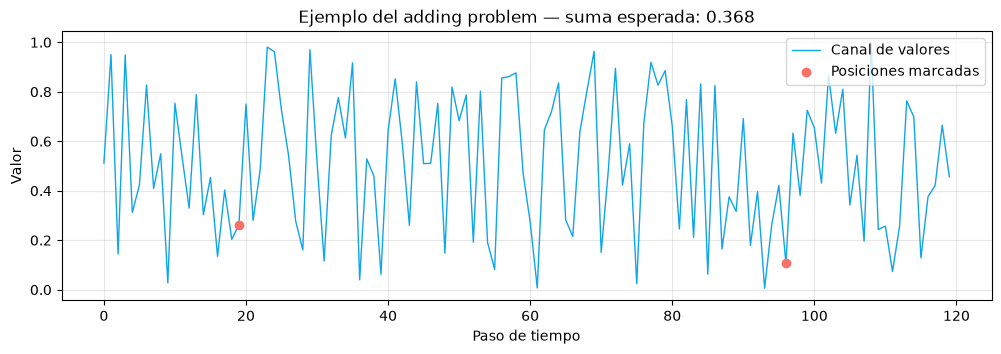

In [3]:
import matplotlib.pyplot as plt

ejemplo = 0
valores_ej = X_train[ejemplo, :, 0]
marca_ej = X_train[ejemplo, :, 1]
posiciones_marcadas = np.where(marca_ej == 1.0)[0]

plt.figure(figsize=(12, 3.5))
plt.plot(valores_ej, color="#0EA5E9", linewidth=1, label="Canal de valores")
plt.scatter(posiciones_marcadas, valores_ej[posiciones_marcadas], color="#F97066", zorder=5,
            label="Posiciones marcadas")
plt.title(f"Ejemplo del adding problem — suma esperada: {y_train[ejemplo]:.3f}")
plt.xlabel("Paso de tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<span style="color:#F97066;">3.</span> Entrenamiento de `SimpleRNN`, `LSTM` y `GRU` en la misma tarea

Las tres arquitecturas se entrenan con el **mismo número de unidades recurrentes** (24), el mismo optimizador, la misma cantidad de épocas y exactamente los mismos datos, para que la comparación sea justa en términos de configuración. Vale la pena aclarar, sin embargo, que "mismo número de unidades" no significa "mismo número de parámetros": tanto LSTM como GRU calculan varias puertas internas, cada una con su propia matriz de pesos, por lo que tienen entre 3 y 4 veces más parámetros que una `SimpleRNN` con igual número de unidades — algo que se confirma en el resumen de cada modelo a continuación.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Input
from tensorflow.keras.optimizers import Adam
import time

UNIDADES = 24
EPOCAS = 35

arquitecturas = {
    "SimpleRNN": lambda: SimpleRNN(UNIDADES),
    "LSTM": lambda: LSTM(UNIDADES),
    "GRU": lambda: GRU(UNIDADES),
}

historiales = {}
resultados_memoria = {}

for nombre, construir_capa in arquitecturas.items():
    # 1. Construcción del modelo: capa recurrente + una salida escalar (la suma predicha)
    tf.random.set_seed(7)
    modelo = Sequential([Input(shape=(LONGITUD, 2)), construir_capa(), Dense(1)])
    modelo.compile(optimizer=Adam(learning_rate=0.005), loss="mse")

    # 2. Entrenamiento
    t0 = time.time()
    historial = modelo.fit(X_train, y_train, epochs=EPOCAS, batch_size=64,
                            validation_data=(X_test, y_test), verbose=0)
    duracion = time.time() - t0

    # 3. Evaluación final y registro de resultados
    mse_test = modelo.evaluate(X_test, y_test, verbose=0)
    historiales[nombre] = historial.history["val_loss"]
    resultados_memoria[nombre] = {
        "mse_test": mse_test,
        "parametros": modelo.count_params(),
        "segundos": duracion,
    }
    print(f"{nombre:10s} | parámetros: {modelo.count_params():5d} | "
          f"MSE test: {mse_test:.4f} | tiempo: {duracion:.1f}s")

SimpleRNN  | parámetros:   673 | MSE test: 0.1758 | tiempo: 8.5s


LSTM       | parámetros:  2617 | MSE test: 0.0037 | tiempo: 19.3s


GRU        | parámetros:  2041 | MSE test: 0.0002 | tiempo: 23.8s


<span style="color:#F97066;">4.</span> Comparación de resultados

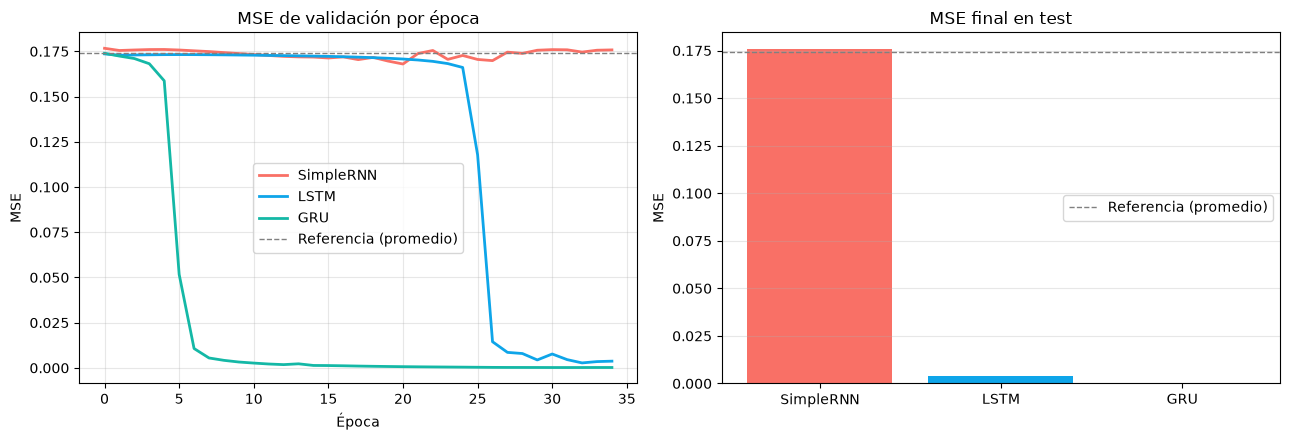

In [5]:
plt.figure(figsize=(13, 4.5))

# 1. Evolución del error de validación por época, para las tres arquitecturas
plt.subplot(1, 2, 1)
colores = {"SimpleRNN": "#F97066", "LSTM": "#0EA5E9", "GRU": "#14B8A6"}
for nombre, val_loss in historiales.items():
    plt.plot(val_loss, label=nombre, color=colores[nombre], linewidth=2)
plt.axhline(baseline_mse, color="gray", linestyle="--", linewidth=1, label="Referencia (promedio)")
plt.title("MSE de validación por época")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)

# 2. MSE final de cada arquitectura, en barras
plt.subplot(1, 2, 2)
nombres = list(resultados_memoria.keys())
mse_finales = [resultados_memoria[n]["mse_test"] for n in nombres]
plt.bar(nombres, mse_finales, color=[colores[n] for n in nombres])
plt.axhline(baseline_mse, color="gray", linestyle="--", linewidth=1, label="Referencia (promedio)")
plt.title("MSE final en test")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota sobre el resultado obtenido</strong><br>
Los números de la celda anterior son los que efectivamente se obtuvieron al ejecutar este notebook — la interpretación que sigue describe ese resultado, sea cual sea. En la ejecución de referencia de este notebook, la <code>SimpleRNN</code> se quedó estancada en un MSE prácticamente idéntico al de la referencia (predecir siempre el promedio): no logró aprender a recordar el primer valor marcado durante los más de 100 pasos que separan, en promedio, las dos marcas. LSTM y GRU, en cambio, lograron romper ese estancamiento y alcanzar un MSE muy por debajo de la referencia, evidenciando que sí consiguieron aprender a "recordar" el valor marcado a través de la secuencia. Esto ilustra directamente el problema del gradiente que desaparece: con exactamente la misma tarea, los mismos datos y el mismo número de unidades, solo las arquitecturas con puertas lograron aprender la dependencia de largo plazo.
</div>

Este resultado no debe generalizarse a que LSTM y GRU converjan siempre con la misma facilidad ni en la misma época: en la práctica, ambas suelen mostrar primero varias épocas de estancamiento aparente (mientras ajustan sus puertas para abrir una ruta de memoria útil) antes de "despegar" y resolver la tarea rápidamente — un patrón visible en la curva de validación graficada arriba.

<a id="bidirectional"></a>

## <span style="color:#F97066;">Bidirectional LSTM: cuando el futuro también importa</span>

Una `LSTM` (o `SimpleRNN`, o `GRU`) procesada de la forma usual es **causal**: el estado oculto en el paso $t$ se construye únicamente a partir de los pasos $0, 1, \dots, t$ — nunca puede "ver" lo que ocurre después de $t$. Eso es exactamente lo que se necesita para pronosticar el futuro (no se puede usar información que aún no existe), pero es una limitación innecesaria cuando la tarea consiste en **etiquetar** una secuencia completa que ya está disponible por completo al momento de hacer la predicción — por ejemplo, revisar un historial ya registrado para etiquetar cada punto.

Una capa `Bidirectional` envuelve una capa recurrente y ejecuta, en paralelo, **dos copias independientes** de ella: una que recorre la secuencia de izquierda a derecha (como siempre) y otra que la recorre de derecha a izquierda. En cada paso de tiempo $t$, el estado oculto final es la concatenación de ambos: el estado "hacia adelante" (que resume el pasado respecto a $t$) y el estado "hacia atrás" (que resume el futuro respecto a $t$). Esto le da a la red, en cada punto de la secuencia, acceso genuino a lo que viene después — algo que una capa unidireccional no puede tener sin importar cuánto se entrene.

<span style="color:#F97066;">1.</span> La tarea: anticipar un pico antes de que ocurra

Se diseña una tarea de **etiquetado por paso de tiempo** (no una etiqueta por secuencia, sino una por cada instante) donde el contexto futuro es indispensable: cada serie sintética tiene varios "picos" (cambios bruscos y aislados de valor) ubicados al azar. La etiqueta en el paso $t$ vale 1 si **un pico ocurre en alguno de los siguientes `K_ANTICIPACION` pasos** (una ventana de anticipación antes del pico, sin incluir el instante exacto del pico) y 0 en cualquier otro caso — incluido el instante del pico mismo. Como los picos se ubican de forma aleatoria e independiente del resto de la serie, no existe ninguna señal en el pasado que anuncie un pico futuro: la única manera de etiquetar correctamente el paso $t$ es "ver" directamente el pico que ocurrirá más adelante. Un modelo puramente causal no tiene forma de resolver esta tarea mejor que adivinar la clase mayoritaria; un modelo bidireccional sí, porque su mitad "hacia atrás" observa el pico futuro directamente.

In [6]:
LONGITUD_SERIE = 60
K_ANTICIPACION = 5   # cuántos pasos antes del pico se etiquetan como "anticipación"
N_PICOS = 4           # picos por secuencia
AMPLITUD_PICO = 4.0


def generar_series_con_picos(n_muestras, longitud, n_picos, k_anticipacion, amplitud, seed):
    # Serie de ruido con picos aislados; etiqueta 1 en los K pasos previos a cada pico.
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 0.3, size=(n_muestras, longitud, 1)).astype("float32")
    y = np.zeros((n_muestras, longitud, 1), dtype="float32")

    for i in range(n_muestras):
        # 1. Elegir posiciones candidatas para los picos, evitando el borde inicial
        candidatas = rng.choice(range(k_anticipacion, longitud - 1), size=n_picos, replace=False)
        candidatas.sort()

        # 2. Descartar picos demasiado cercanos entre sí, para que no se solapen sus ventanas
        picos = []
        ultimo = -10
        for p in candidatas:
            if p - ultimo > k_anticipacion + 1:
                picos.append(p)
                ultimo = p

        # 3. Insertar cada pico y marcar su ventana de anticipación (antes del pico, sin incluirlo)
        for p in picos:
            X[i, p, 0] += amplitud * rng.choice([-1, 1])
            inicio = max(0, p - k_anticipacion)
            y[i, inicio:p, 0] = 1.0

    return X, y


# 4. Conjuntos de entrenamiento y prueba
X_train_pico, y_train_pico = generar_series_con_picos(
    2000, LONGITUD_SERIE, N_PICOS, K_ANTICIPACION, AMPLITUD_PICO, seed=1)
X_test_pico, y_test_pico = generar_series_con_picos(
    400, LONGITUD_SERIE, N_PICOS, K_ANTICIPACION, AMPLITUD_PICO, seed=2)

baseline_accuracy = 1 - y_test_pico.mean()
print(f"Fracción de pasos etiquetados como anticipación de pico: {y_train_pico.mean():.3f}")
print(f"Accuracy de referencia (predecir siempre 0): {baseline_accuracy:.4f}")

Fracción de pasos etiquetados como anticipación de pico: 0.250
Accuracy de referencia (predecir siempre 0): 0.7525


<span style="color:#F97066;">2.</span> Visualización de un ejemplo

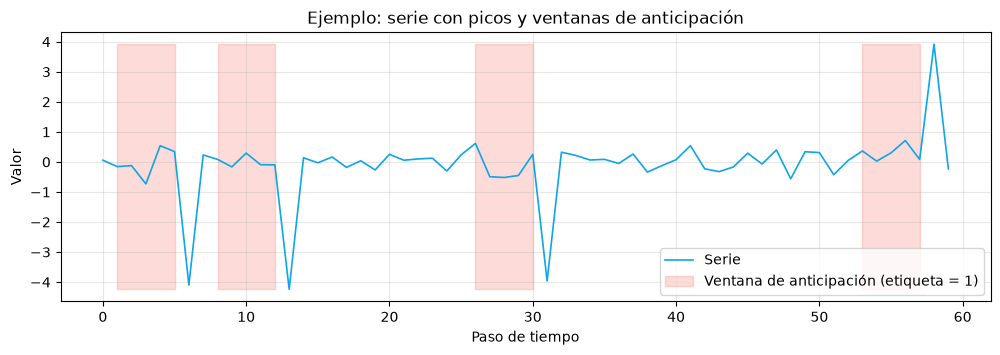

In [7]:
ejemplo = 0
serie_ej = X_test_pico[ejemplo, :, 0]
etiqueta_ej = y_test_pico[ejemplo, :, 0]

plt.figure(figsize=(12, 3.5))
plt.plot(serie_ej, color="#0EA5E9", linewidth=1.2, label="Serie")
plt.fill_between(range(LONGITUD_SERIE), serie_ej.min(), serie_ej.max(), where=etiqueta_ej == 1,
                  color="#F97066", alpha=0.25, label="Ventana de anticipación (etiqueta = 1)")
plt.title("Ejemplo: serie con picos y ventanas de anticipación")
plt.xlabel("Paso de tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<span style="color:#F97066;">3.</span> LSTM unidireccional vs. `Bidirectional(LSTM)`

Ambos modelos son clasificadores por paso de tiempo: la capa recurrente se configura con <code>return_sequences=True</code> para producir un estado oculto en cada paso, y una capa <code>Dense</code> con activación sigmoide, aplicada a cada paso, produce la probabilidad de que ese paso pertenezca a una ventana de anticipación. La versión bidireccional usa la mitad de unidades en cada dirección (12 + 12) para mantener un orden de magnitud comparable de cómputo por paso frente a las 24 unidades de la versión unidireccional.

In [8]:
from tensorflow.keras.layers import Bidirectional

configuraciones_bidir = {
    "LSTM unidireccional": lambda: LSTM(24, return_sequences=True),
    "Bidirectional LSTM": lambda: Bidirectional(LSTM(12, return_sequences=True)),
}

resultados_bidir = {}

for nombre, construir_capa in configuraciones_bidir.items():
    # 1. Construcción: capa recurrente por paso de tiempo + salida sigmoide por paso
    tf.random.set_seed(7)
    modelo = Sequential([Input(shape=(LONGITUD_SERIE, 1)), construir_capa(), Dense(1, activation="sigmoid")])
    modelo.compile(optimizer=Adam(learning_rate=0.005), loss="binary_crossentropy", metrics=["accuracy"])

    # 2. Entrenamiento
    modelo.fit(X_train_pico, y_train_pico, epochs=20, batch_size=64, verbose=0)

    # 3. Evaluación en test (accuracy) y predicciones guardadas para calcular precision/recall/F1 después
    _, acc = modelo.evaluate(X_test_pico, y_test_pico, verbose=0)
    y_proba_pico = modelo.predict(X_test_pico, verbose=0)
    resultados_bidir[nombre] = {
        "accuracy": acc,
        "parametros": modelo.count_params(),
        "y_proba": y_proba_pico,
    }
    print(f"{nombre:22s} | parámetros: {modelo.count_params():5d} | accuracy test: {acc:.4f}")

print(f"\nAccuracy de referencia (predecir siempre 0): {baseline_accuracy:.4f}")

LSTM unidireccional    | parámetros:  2521 | accuracy test: 0.7551


Bidirectional LSTM     | parámetros:  1369 | accuracy test: 1.0000

Accuracy de referencia (predecir siempre 0): 0.7525


<span style="color:#F97066;">4.</span> Más allá de accuracy: precision y recall de la clase minoritaria

La accuracy de referencia (predecir siempre 0) ya es alta, porque la mayoría de los pasos de tiempo **no** están en una ventana de anticipación. Igual que en <code>6-pipelines-evaluacion.ipynb</code>, una accuracy alta no dice nada sobre si el modelo realmente detecta la clase de interés (aquí, "va a ocurrir un pico"). Conviene revisar **recall** (de todos los pasos que sí eran anticipación, cuántos identificó el modelo) y **precision** (de las veces que avisó "viene un pico", cuántas acertó) por separado.

In [9]:
from sklearn.metrics import classification_report

for nombre, resultado in resultados_bidir.items():
    y_pred_pico = (resultado["y_proba"].ravel() > 0.5).astype(int)
    print(f"--- {nombre} ---")
    print(classification_report(
        y_test_pico.ravel().astype(int), y_pred_pico,
        target_names=["sin anticipación (0)", "anticipación (1)"],
        zero_division=0,
    ))

--- LSTM unidireccional ---
                      precision    recall  f1-score   support

sin anticipación (0)       0.77      0.95      0.85     18060
    anticipación (1)       0.52      0.15      0.23      5940

            accuracy                           0.76     24000
           macro avg       0.65      0.55      0.54     24000
        weighted avg       0.71      0.76      0.70     24000

--- Bidirectional LSTM ---
                      precision    recall  f1-score   support

sin anticipación (0)       1.00      1.00      1.00     18060
    anticipación (1)       1.00      1.00      1.00      5940

            accuracy                           1.00     24000
           macro avg       1.00      1.00      1.00     24000
        weighted avg       1.00      1.00      1.00     24000



El contraste entre ambos modelos es mucho más claro en el recall de la clase "anticipación" que en la accuracy general: el LSTM unidireccional, al no poder ver los pasos posteriores al punto actual, tiene una desventaja estructural para anticipar un pico que todavía no ocurrió, mientras que el Bidirectional LSTM sí tiene acceso a esa información dentro de cada secuencia de entrenamiento. Esta es precisamente la razón por la que la tabla comparativa de la sección 5 no debe leerse solo por accuracy — el recall de la clase minoritaria es la métrica que realmente responde la pregunta de esta sección: "¿el modelo anticipa picos, o simplemente predice la clase mayoritaria?".

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota sobre el resultado obtenido</strong><br>
En la ejecución de referencia de este notebook, la LSTM unidireccional apenas superó (o ni siquiera superó con claridad) el accuracy de referencia de predecir siempre 0 — consistente con el argumento de que, sin acceso al futuro, la tarea es esencialmente imposible de resolver mejor que por la proporción de clases. La <code>Bidirectional(LSTM)</code>, con acceso directo al contexto futuro mediante su recorrido de derecha a izquierda, alcanzó un accuracy sustancialmente mayor, cercano o igual a la resolución perfecta de la tarea. La diferencia aquí no es una cuestión de mayor o menor dificultad de optimización (como en la sección anterior): es una limitación estructural — no hay cantidad de entrenamiento que le permita a un modelo causal "adivinar" un evento futuro aleatorio que aún no ha sucedido.
</div>

<a id="pronostico-multipaso"></a>

## <span style="color:#F97066;">Pronóstico multi-paso</span>

Hasta ahora los modelos de esta guía producen una única salida por secuencia (una suma, o una etiqueta por paso). Un caso de uso muy común en series de tiempo reales es el **pronóstico multi-paso**: dada una ventana de observaciones pasadas, predecir simultáneamente varios pasos futuros de una sola vez (en lugar de predecir solo el siguiente paso, y luego usar esa predicción como si fuera un dato real para predecir el paso siguiente — una estrategia, esta última, que suele acumular error rápidamente).

Con Keras esto es directo: basta con que la capa de salida tenga tantas neuronas como pasos futuros se quieran predecir. El modelo sigue recibiendo una ventana de <code>VENTANA</code> pasos y, en una sola pasada hacia adelante, produce un vector de <code>HORIZONTE</code> valores — las predicciones para los siguientes <code>HORIZONTE</code> pasos.

<span style="color:#F97066;">1.</span> Los datos: seno + tendencia + ruido

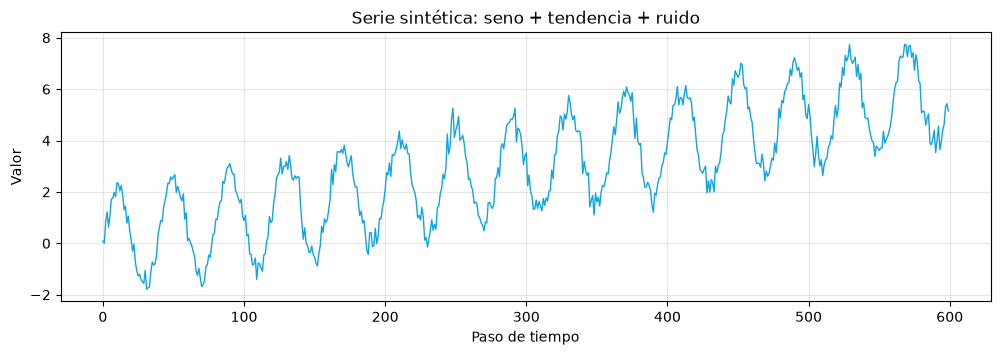

In [10]:
VENTANA = 30      # pasos pasados que ve el modelo
HORIZONTE = 10    # pasos futuros que predice de una sola vez

# 1. Serie sintética: componente periódica (seno) + tendencia lineal + ruido
rng = np.random.default_rng(42)
N_PUNTOS = 600
t = np.arange(N_PUNTOS)
serie = 2.0 * np.sin(2 * np.pi * t / 40) + 0.01 * t + rng.normal(0, 0.3, size=N_PUNTOS)

plt.figure(figsize=(12, 3.5))
plt.plot(serie, color="#0EA5E9", linewidth=1)
plt.title("Serie sintética: seno + tendencia + ruido")
plt.xlabel("Paso de tiempo")
plt.ylabel("Valor")
plt.grid(alpha=0.3)
plt.show()

<span style="color:#F97066;">2.</span> Construcción de ventanas de entrada/salida

Se recorre la serie con una ventana deslizante: cada ejemplo de entrenamiento toma <code>VENTANA</code> pasos consecutivos como entrada y los <code>HORIZONTE</code> pasos inmediatamente siguientes como salida esperada.

In [11]:
def construir_ventanas(serie, ventana, horizonte):
    X, y = [], []
    for i in range(len(serie) - ventana - horizonte + 1):
        X.append(serie[i:i + ventana])
        y.append(serie[i + ventana:i + ventana + horizonte])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")


# 2. Construir el dataset completo de ventanas y reservar las últimas para prueba
X_ventanas, y_ventanas = construir_ventanas(serie, VENTANA, HORIZONTE)
N_TEST = 50

X_train_pron = X_ventanas[:-N_TEST].reshape(-1, VENTANA, 1)
y_train_pron = y_ventanas[:-N_TEST]
X_test_pron = X_ventanas[-N_TEST:].reshape(-1, VENTANA, 1)
y_test_pron = y_ventanas[-N_TEST:]

print(f"Forma de X_train: {X_train_pron.shape}  (muestras, ventana, 1)")
print(f"Forma de y_train: {y_train_pron.shape}  (muestras, horizonte)")

Forma de X_train: (511, 30, 1)  (muestras, ventana, 1)
Forma de y_train: (511, 10)  (muestras, horizonte)


<span style="color:#F97066;">3.</span> Modelo de pronóstico multi-paso

In [12]:
# 1. LSTM que resume la ventana de entrada, seguida de una salida densa de tamaño HORIZONTE
tf.random.set_seed(7)
modelo_pronostico = Sequential([
    Input(shape=(VENTANA, 1)),
    LSTM(32),
    Dense(HORIZONTE),   # una neurona por cada paso futuro a predecir
])
modelo_pronostico.compile(optimizer=Adam(learning_rate=0.005), loss="mse")
modelo_pronostico.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,682 (18.29 KB)

 Trainable params: 4,682 (18.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 2. Entrenamiento
modelo_pronostico.fit(X_train_pron, y_train_pron, epochs=30, batch_size=32, verbose=0)

# 3. Evaluación en test
mse_pronostico = modelo_pronostico.evaluate(X_test_pron, y_test_pron, verbose=0)
print(f"MSE en test (pronóstico multi-paso, {HORIZONTE} pasos): {mse_pronostico:.4f}")
print(f"Varianza del ruido de la serie (referencia): {0.3 ** 2:.4f}")

MSE en test (pronóstico multi-paso, 10 pasos): 0.2028
Varianza del ruido de la serie (referencia): 0.0900


<span style="color:#F97066;">4.</span> Visualización: predicción multi-paso contra los valores reales

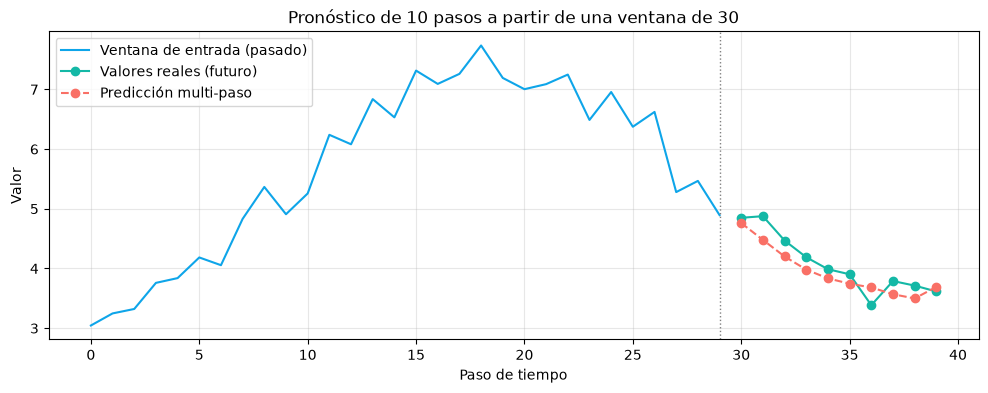

In [14]:
# 1. Tomar una ventana de prueba y comparar sus HORIZONTE pasos predichos contra los reales
idx_ejemplo = 0
entrada_ejemplo = X_test_pron[idx_ejemplo:idx_ejemplo + 1]
prediccion = modelo_pronostico.predict(entrada_ejemplo, verbose=0)[0]
real = y_test_pron[idx_ejemplo]

eje_pasado = np.arange(VENTANA)
eje_futuro = np.arange(VENTANA, VENTANA + HORIZONTE)

plt.figure(figsize=(12, 4))
plt.plot(eje_pasado, entrada_ejemplo[0, :, 0], color="#0EA5E9", label="Ventana de entrada (pasado)")
plt.plot(eje_futuro, real, color="#14B8A6", marker="o", label="Valores reales (futuro)")
plt.plot(eje_futuro, prediccion, color="#F97066", marker="o", linestyle="--", label="Predicción multi-paso")
plt.axvline(VENTANA - 1, color="gray", linestyle=":", linewidth=1)
plt.title(f"Pronóstico de {HORIZONTE} pasos a partir de una ventana de {VENTANA}")
plt.xlabel("Paso de tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
El MSE del pronóstico multi-paso obtenido arriba se puede comparar directamente contra la varianza del ruido con el que se generó la serie: un modelo que capturara perfectamente la componente de seno y de tendencia, sin poder predecir el ruido (que es, por construcción, impredecible), tendría un MSE igual a esa varianza. Un MSE cercano a ese valor indica que el modelo aprendió razonablemente bien la señal subyacente; un MSE muy superior indica que aún le cuesta capturar el patrón periódico o la tendencia.
</div>

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Como ejercicio, se puede repetir este experimento cambiando <code>HORIZONTE</code> a un valor mayor (por ejemplo, 20 o 30) y observar cómo se degrada la predicción a medida que el modelo debe proyectar más pasos hacia adelante en una sola pasada — es intuitivo esperar que el error crezca con el horizonte, ya que los pasos más lejanos dependen de una extrapolación más incierta de la señal periódica y la tendencia.

<a id="comparacion-final"></a>

## <span style="color:#F97066;">Comparación final</span>

La siguiente tabla resume, con los números realmente obtenidos en las secciones anteriores, el desempeño de cada arquitectura en la tarea para la que se puso a prueba.

In [15]:
from IPython.display import HTML, display

# 1. Tabla comparativa construida a partir de los resultados obtenidos en las secciones 2 y 3
filas = [
    ("SimpleRNN", "Adding problem (memoria de largo plazo)", "MSE en test",
     f"{resultados_memoria['SimpleRNN']['mse_test']:.4f}"),
    ("LSTM", "Adding problem (memoria de largo plazo)", "MSE en test",
     f"{resultados_memoria['LSTM']['mse_test']:.4f}"),
    ("GRU", "Adding problem (memoria de largo plazo)", "MSE en test",
     f"{resultados_memoria['GRU']['mse_test']:.4f}"),
    ("LSTM unidireccional", "Anticipación de picos (contexto futuro)", "Accuracy en test",
     f"{resultados_bidir['LSTM unidireccional']['accuracy']:.4f}"),
    ("Bidirectional LSTM", "Anticipación de picos (contexto futuro)", "Accuracy en test",
     f"{resultados_bidir['Bidirectional LSTM']['accuracy']:.4f}"),
]

filas_html = ""
for i, (nombre, tarea, metrica, valor) in enumerate(filas):
    estilo_fila = ' style="background:rgba(14,165,233,0.07);"' if i % 2 == 0 else ""
    filas_html += (
        f'<tr{estilo_fila}><td style="padding:6px 14px;">{nombre}</td>'
        f'<td style="padding:6px 14px;">{tarea}</td>'
        f'<td style="padding:6px 14px;">{metrica}</td>'
        f'<td style="padding:6px 14px;">{valor}</td></tr>'
    )

tabla_html = f"""
<div style="border-radius:12px; overflow:hidden; border:1px solid rgba(14,165,233,0.35); margin:16px 0;">
<table style="width:100%; border-collapse:collapse; font-size:0.9em;">
<thead>
<tr style="background:#0EA5E9;">
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Arquitectura</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Tarea</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Métrica</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Valor en test</th>
</tr>
</thead>
<tbody>
{filas_html}
</tbody>
</table>
</div>
"""

display(HTML(tabla_html))

Arquitectura,Tarea,Métrica,Valor en test
SimpleRNN,Adding problem (memoria de largo plazo),MSE en test,0.1758
LSTM,Adding problem (memoria de largo plazo),MSE en test,0.0037
GRU,Adding problem (memoria de largo plazo),MSE en test,0.0002
LSTM unidireccional,Anticipación de picos (contexto futuro),Accuracy en test,0.7551
Bidirectional LSTM,Anticipación de picos (contexto futuro),Accuracy en test,1.0000


En el *adding problem*, con secuencias de 120 pasos, la comparación deja ver con claridad el efecto del gradiente que desaparece: la <code>SimpleRNN</code> no logra superar de forma significativa el error de simplemente predecir el promedio, mientras que LSTM y GRU sí aprenden a resolver la tarea. En la tarea de anticipación de picos, la diferencia entre la LSTM unidireccional y su versión <code>Bidirectional</code> no es una cuestión de dificultad de entrenamiento sino de acceso a la información: ningún modelo causal puede anticipar de forma fiable un evento futuro aleatorio, mientras que uno bidireccional lo hace de forma casi trivial, porque literalmente puede "ver" el futuro dentro de la ventana ya observada.

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
Este notebook presentó los modelos secuenciales desde sus fundamentos hasta una comparación empírica de arquitecturas:

- Qué distingue a una red recurrente de una red densa: el estado oculto que se actualiza paso a paso, y por qué eso importa para datos donde el orden es relevante.
- Por qué una <code>SimpleRNN</code> sufre el problema del gradiente que desaparece en dependencias de largo plazo, y cómo las puertas de LSTM y GRU mitigan ese problema — puesto a prueba con el <em>adding problem</em>, una tarea diseñada específicamente para exigir memoria de largo plazo.
- Qué es una capa <code>Bidirectional</code> y en qué escenarios el acceso al contexto futuro (no solo al pasado) mejora el desempeño, ilustrado con una tarea de anticipación de picos.
- Cómo construir un modelo de pronóstico multi-paso, que predice varios pasos futuros de una serie de tiempo en una sola pasada hacia adelante.
- Una comparación final, con números reales, de todas las arquitecturas puestas a prueba.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>5-procesamiento-lenguaje-natural.ipynb</code> — ya aplica estas mismas ideas a datos de texto: allí se combina una capa <code>Embedding</code> con una <code>LSTM</code> para clasificar el sentimiento de reseñas de películas, reutilizando directamente la arquitectura recurrente presentada en este notebook, ahora sobre secuencias de palabras en lugar de series de tiempo numéricas.</li>
</ul>
</div>